In [ ]:
import numpy as np 
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report

from xgboost import XGBClassifier



In [ ]:

df = pd.read_csv(r'C:\Users\kulde\kuldeepcode\loan\loan_real_dataset.csv')

##### Data Understanding 

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.isna().sum()

In [ ]:
df['City'].value_counts()

In [ ]:
df['Education'].value_counts()

In [ ]:
df['Marital_Status'].value_counts()

In [ ]:
df['Loan_Purpose'].value_counts()

In [ ]:
df.describe()

In [ ]:
df.shape

##### Data visualization 

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 22))

# 1. Age distribution
sns.histplot(df['Age'], ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

# 2. Salary vs Loan Approved
sns.boxplot(x='Loan_Approved', y='Salary', data=df, ax=axes[0,1])
axes[0,1].set_title("Salary vs Approval")

# 3. Credit Score vs Loan Approved
sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df, ax=axes[1,0])
axes[1,0].set_title("Credit Score vs Approval")

# 4. Job Type count
sns.countplot(x='Job_Type', data=df, ax=axes[1,1])
axes[1,1].set_title("Job Type Count")
axes[1,1].tick_params(axis='x', rotation=45)

sns.scatterplot(x='Salary', y='Loan_Amount', data=df, ax=axes[2,0])
axes[0,1].set_title('Loan Amount & Salary')
axes[0,1].tick_params(axis='x')

plt.tight_layout()
plt.show()

##### Data Cleaning and Handle With Pipeline

In [ ]:
df.info()
df.head()

In [ ]:
# Feature Engineering
 
df["Risk_Level"] = df["Credit_Score"].apply(lambda x: "High" if x < 500 else "Low")


df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 28, 50, 100],
    labels=['child',"Young", "Adult", "Old"]
)


In [ ]:
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [ ]:
num = X.select_dtypes(include=['int64', 'float64']).columns
cat = X.select_dtypes(include=['object', 'category', 'str']).columns

In [ ]:
processor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat),
    ('num', StandardScaler(), num)
])

##### LogisticRegression

In [ ]:
model = Pipeline(steps=[
    ('preprocess', processor),
    ('model', LogisticRegression(random_state=42, max_iter=200))
])

In [ ]:
model.fit(X_train, y_train)

In [ ]:
model_pred = model.predict(X_test)

accuracy = accuracy_score( y_test, model_pred)

report = classification_report(y_test, model_pred)


In [ ]:
print(accuracy)
print(report)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model_pred)
print(cm)

In [ ]:
print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))

In [ ]:
scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

##### RandomForestClassifier

In [ ]:
forset = Pipeline(steps=[
    ('processor', processor),
    ('Classifier', RandomForestClassifier(n_estimators=300,
    random_state=42)),  
])

In [ ]:
forset.fit(X_train, y_train)

In [ ]:
f_pre = forset.predict(X_test)

In [ ]:

f_accuracy = accuracy_score(y_test, f_pre)
print(f_accuracy)

In [ ]:
f_report = classification_report(y_test, f_pre)
print(f_report)

##### XGBoost

In [86]:
xgb = Pipeline(steps=[
    ('processor', processor),
    ('xgb_class', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ) )
])

In [ ]:
xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processor', ...), ('xgb_class', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Salary','Experience',...,'Loan_Purpose','Risk_Level','Age_Group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [88]:
xgb_pre = xgb.predict(X_test)

In [89]:
xgb_Accurecy = accuracy_score(y_test, xgb_pre)
print(xgb_Accurecy)

0.9240666666666667


In [94]:
scores = cross_val_score(xgb, X, y, cv=5)
print(scores)

[0.9225 0.9187 0.9228 0.9262 0.9234]


In [98]:
xgb_model = xgb.named_steps['xgb_class']
processor = xgb.named_steps['processor']

In [99]:
feature_names = processor.get_feature_names_out()

In [100]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
)

importance = importance.sort_values(ascending=False)
print(importance.head(10))

cat__Risk_Level_High            0.238159
num__Existing_Loans             0.176854
num__Credit_Score               0.176127
num__EMI_Burden                 0.119886
num__Salary                     0.068488
cat__Education_High School      0.055270
cat__Job_Type_Government Job    0.038823
num__Experience                 0.019743
cat__Job_Type_Private Job       0.007145
cat__City_Jaipur                0.006257
dtype: float32


<Axes: >

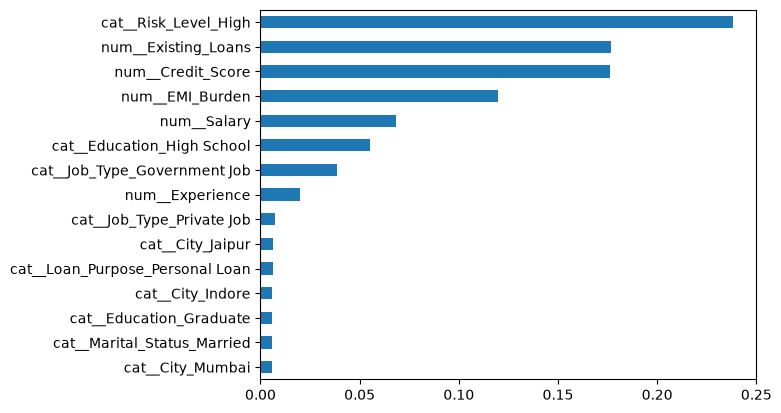

In [101]:
importance.head(15).sort_values().plot(kind='barh')